In [1]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    aggregated = [X1[i] + X2[i] for i in range(len(X1))]

    state_neuron = []
    for total in aggregated:
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

# Test it
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate: {result}")

Output of AND gate: [0, 0, 0, 1]


In [2]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    aggregated = [X1[i] + X2[i] for i in range(len(X1))]

    state_neuron = []
    for total in aggregated:
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

# Test it
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate: {result_or}")


Output of OR gate: [0, 1, 1, 1]


Q1)
1. Weights are fixed and hand-crafted — the MCP neuron cannot learn from data.
2. Only accepts binary inputs (0 or 1), not real-valued data.
3. Only produces binary output (0 or 1).
4. Cannot solve non-linearly separable problems like XOR.
5. Has no learning algorithm — it cannot adjust itself based on errors.
6. All inputs are treated equally — no input can be prioritised over another.

Q2)
No. XOR outputs 1 when inputs are different (0,1) or (1,0),
and 0 when they are the same (0,0) or (1,1).

With MCP, g(X) = X1 + X2 gives sums: 0, 1, 1, 2.
No single threshold T can separate these correctly
because sum=1 should output 1, but sum=0 and sum=2 should output 0.
XOR is not linearly separable — a single MCP neuron cannot solve it.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Q1)
X has shape (12665, 784).
12665 = total number of images in the dataset.
784 = each image is 28x28 pixels flattened into a single row.

Q2)
y has shape (12665,).
It is a 1D array where each element is the label (0 or 1)
for the corresponding image in X.

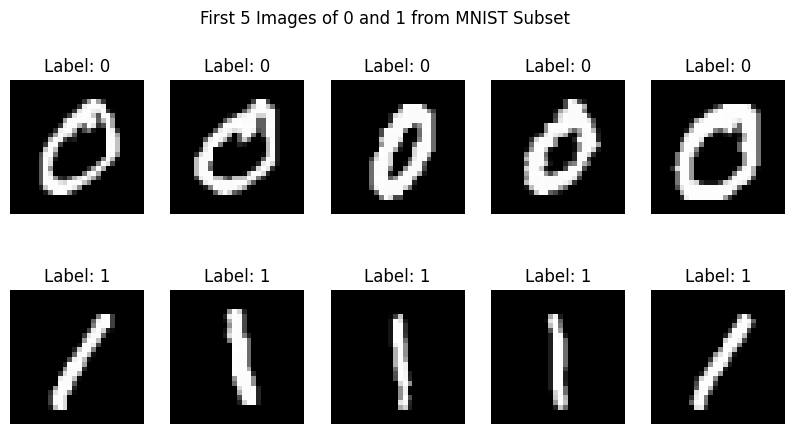

In [4]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

In [5]:
weights = np.zeros(X.shape[1])  # 784 weights, one per pixel
bias = 0
learning_rate = 0.1
epochs = 100

print("Weights shape:", weights.shape)
print("Initial bias:", bias)

Weights shape: (784,)
Initial bias: 0


The weights array has 784 values, one for each pixel in the image.
Each weight controls how much influence that pixel has on the
perceptron's final decision.

We initialise to zero as a neutral starting point so the perceptron
makes no assumptions before seeing any data.
The weights will gradually update during training based on errors.
This works fine for a single perceptron since it will still converge
for linearly separable data.

In [6]:
def decision_function(X, weights, bias):
    net_input = np.dot(X, weights) + bias
    y_pred_all = np.where(net_input >= 0, 1, 0)
    return y_pred_all

# Quick test before training
initial_preds = decision_function(X, weights, bias)
print("Initial predictions (first 10):", initial_preds[:10])
print("True labels         (first 10):", y[:10])

Initial predictions (first 10): [1 1 1 1 1 1 1 1 1 1]
True labels         (first 10): [0 1 1 1 1 0 1 1 0 0]


In [9]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True

        for i in range(n_samples):
            # Compute weighted sum
            output = np.dot(X[i], weights) + bias

            # Apply step activation
            y_hat = 1 if output >= 0 else 0

            # Update weights only if prediction is wrong
            if y_hat != y[i]:
                error = y[i] - y_hat
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error
                convergence_flag = False

        if convergence_flag:
            print(f"Converged after {epoch + 1} epoch(s).")
            break

    y_pred_all = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

In [10]:
# Reset weights and bias before training
weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("The Final Accuracy is:", accuracy)

Converged after 13 epoch(s).
The Final Accuracy is: 1.0


In [11]:
# Reset weights and bias before training
weights = np.zeros(X.shape[1])
bias = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("The Final Accuracy is:", accuracy)

Converged after 13 epoch(s).
The Final Accuracy is: 1.0


misclassified_idx stores the indices of all samples where the
perceptron's prediction did not match the true label.
It is used to index back into X and y so we can display the
misclassified images along with their predicted and true labels.

It means the perceptron found a perfect linear decision boundary
that separates all 0s from all 1s in the dataset.
This is expected because digits 0 and 1 look very different
from each other, making them easy to separate.

In [12]:
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

X35 = df_3_5.drop(columns=["label"]).values
y35 = df_3_5["label"].values

# Remap labels: 3 → 0 and 5 → 1 (perceptron needs 0/1 labels)
y35_binary = np.where(y35 == 3, 0, 1)

print("Feature matrix shape:", X35.shape)
print("Label vector shape:", y35.shape)
print("Unique labels:", np.unique(y35))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Unique labels: [3 5]


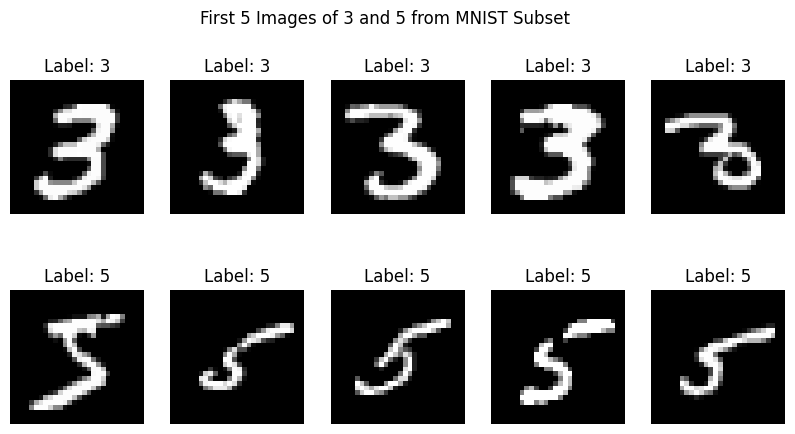

In [13]:
images_3 = X35[y35 == 3]
images_5 = X35[y35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.show()

Final Accuracy: 0.986866107260124


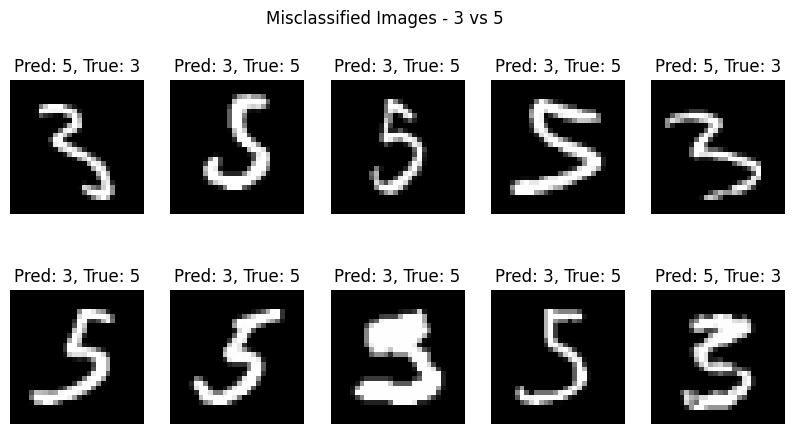

In [15]:
# Train
weights35 = np.zeros(X35.shape[1])
bias35 = 0

weights35, bias35, accuracy35 = train_perceptron(X35, y35_binary, weights35, bias35)
print("Final Accuracy:", accuracy35)

# Misclassified
predictions35 = np.dot(X35, weights35) + bias35
y_pred35 = np.where(predictions35 >= 0, 1, 0)
y_pred35_orig = np.where(y_pred35 == 0, 3, 5)

misclassified_idx35 = np.where(y_pred35 != y35_binary)[0]

if len(misclassified_idx35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx35[:10]):
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred35_orig[idx]}, True: {y35[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images - 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion - 3 vs 5 Classification:

The perceptron did not achieve 100% accuracy like it did for 0 vs 1.
This is because 3 and 5 look very similar to each other, sharing
curved strokes and similar shapes.

The misclassified images show ambiguous digits that are hard to
distinguish even for humans.

This demonstrates the key limitation of the perceptron — it can only
find a linear decision boundary. Since 3 and 5 are not perfectly
linearly separable in pixel space, some mistakes are inevitable.

To improve accuracy, we would need a multi-layer neural network
with non-linear activation functions.